In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [7]:
df.job_posted_date = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## 🟩 Data Scientist Hourly Salary Box Plot (2.18.1) - Problem

Create a box plot to visualize the distribution of salary_hour_avg for Data Scientist job postings in the United States. Label the x-axis as 'Data Scientist' and the y-axis as 'Hourly Salary ($USD)'.

In [9]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')]

df_DS_US = df_DS_US.dropna(subset='salary_hour_avg')

C:\Users\hieno\AppData\Local\Temp\ipykernel_12692\1446751487.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


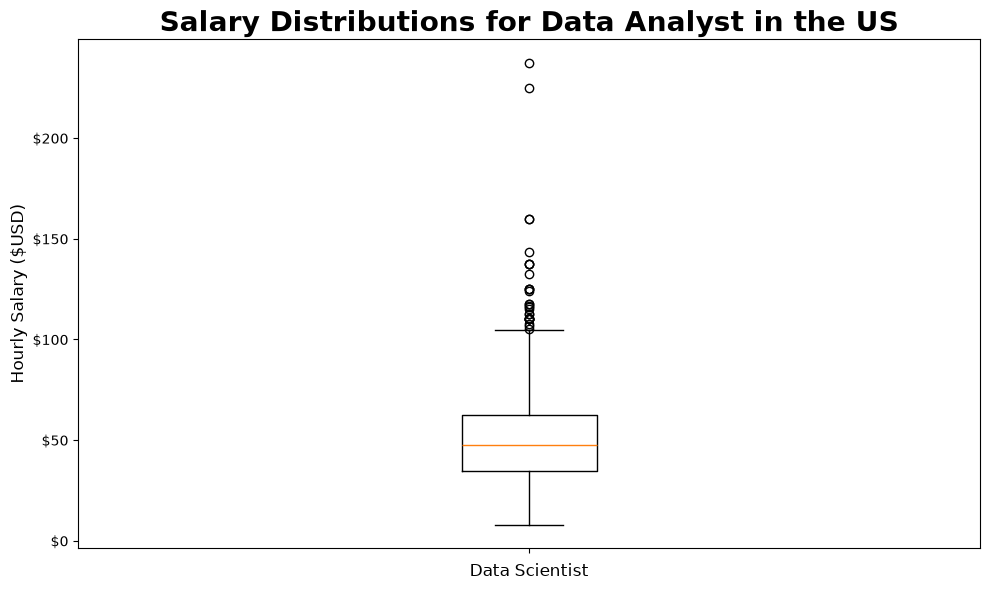

In [ ]:
plt.figure(figsize=(10, 6 ))
plt.boxplot(
            df_DS_US['salary_hour_avg']
            , label = df_DS_US['job_title_short'].unique()
            , vert = True)

# ax = plt.gca()
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x/1000):,}K'))

plt.title(
        'Salary Distributions for Data Analyst in the US'
        , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Data Scientist'
            , fontdict={'fontsize': 12})

plt.ylabel(
            'Hourly Salary ($USD)'
            , fontdict={'fontsize': 12})

ax = plt.gca()
ax.set_xticklabels(labels='')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y)}'))

plt.tight_layout()
plt.show()

# 🟨 Comparison of Hourly Salaries for Data Analyst (2.18.2) - Problem

Create a box plot to compare the distribution of salary_hour_avg for Data Analyst job postings in the United States and Canada.

* Filter a DataFrame to include only 'Data Analyst' roles in these two countries.
* Use list comprehension to create a list of DataFrames for each country.
* Use the plt.boxplot() function to plot this list and specify the labels as countries.
* Set the y-axis limit to 150 and the y-axis as 'Hourly Salary ($USD)'.

In [21]:
countries = ['United States', 'Canada']
df_CAD_US = df[((df['job_country']).isin(countries)) & (df['job_title_short'] == 'Data Analyst')]

df_CAD_US = df_CAD_US.dropna(subset='salary_hour_avg')

In [24]:
countries_list = [df_CAD_US[df_CAD_US['job_country'] == country]['salary_hour_avg'] for country in countries]

C:\Users\hieno\AppData\Local\Temp\ipykernel_12692\3298431002.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


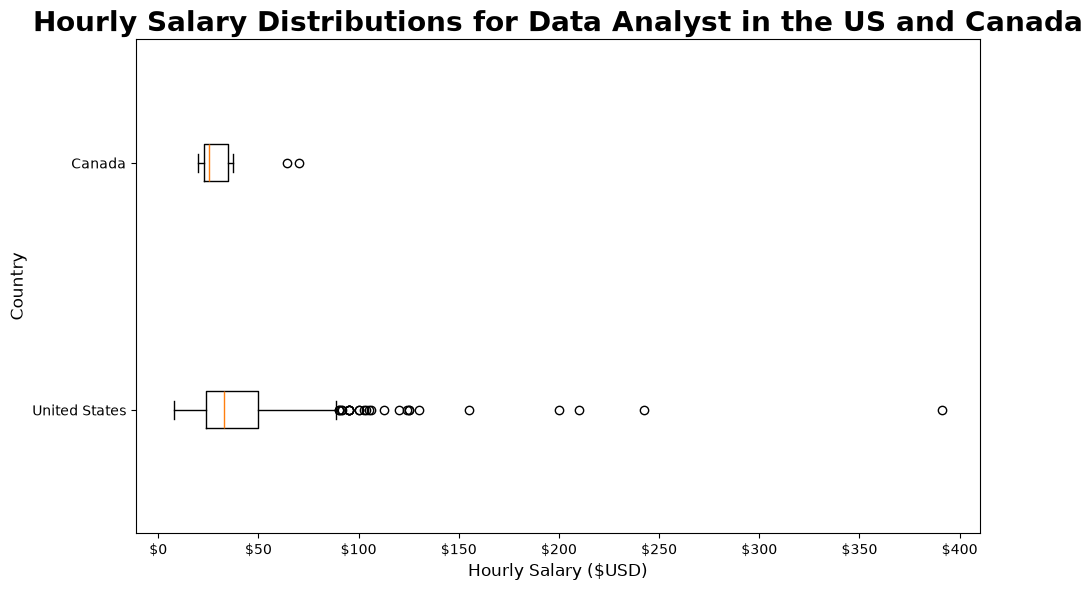

In [35]:
plt.figure(figsize=(10, 6))
plt.boxplot(
            countries_list
            , vert=False)

plt.title(
        'Hourly Salary Distributions for Data Analyst in the US and Canada'
        , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Hourly Salary ($USD)'
            , fontdict={'fontsize': 12})

plt.ylabel(
            'Country'
            , fontdict={'fontsize': 12})

ax = plt.gca()
ax.set_yticklabels(labels=countries)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x)}'))

plt.tight_layout(h_pad=1, w_pad = 1)
plt.show()

C:\Users\hieno\AppData\Local\Temp\ipykernel_12692\3208493893.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


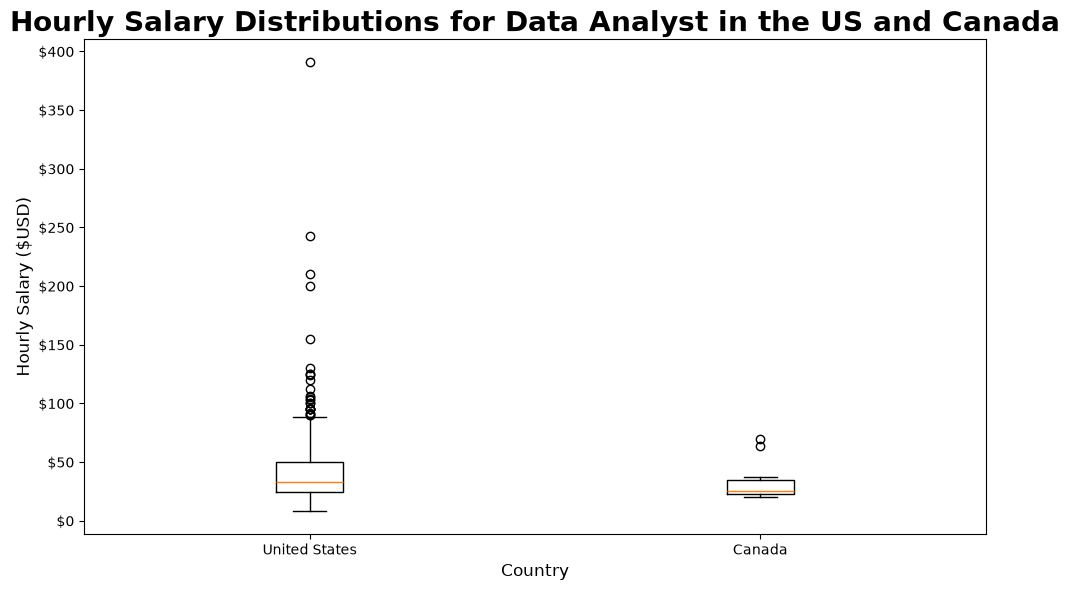

In [42]:
plt.figure(figsize=(10, 6))
plt.boxplot(
            countries_list
            , label=countries
            , vert=True)

plt.title(
        'Hourly Salary Distributions for Data Analyst in the US and Canada'
        , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Country'
            , fontdict={'fontsize': 12})

plt.ylabel(
            'Hourly Salary ($USD)'
            , fontdict={'fontsize': 12})

ax = plt.gca()
ax.set_xticklabels(labels=countries)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y)}'))

plt.tight_layout(h_pad=1, w_pad = 1)
plt.show()

# 🟥 Comparison of Hourly Salaries in Canada (2.18.3) - Problem

* Create a box plot to compare the distribution of salary_hour_avg for Data Analyst, Data Engineer, and Data Scientist job postings in Canada.
* Label the x-axis as 'Job Title' and format the y-axis to have '$' before the number then label it as 'Hourly Salary (USD)'.

In [43]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

In [48]:
df_CAD = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'Canada')]

df_CAD = df_CAD.dropna(subset='salary_hour_avg')

In [59]:
job_list = [df_CAD[df_CAD['job_title_short'] == job]['salary_hour_avg'] for job in job_titles]

C:\Users\hieno\AppData\Local\Temp\ipykernel_12692\2194704784.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list


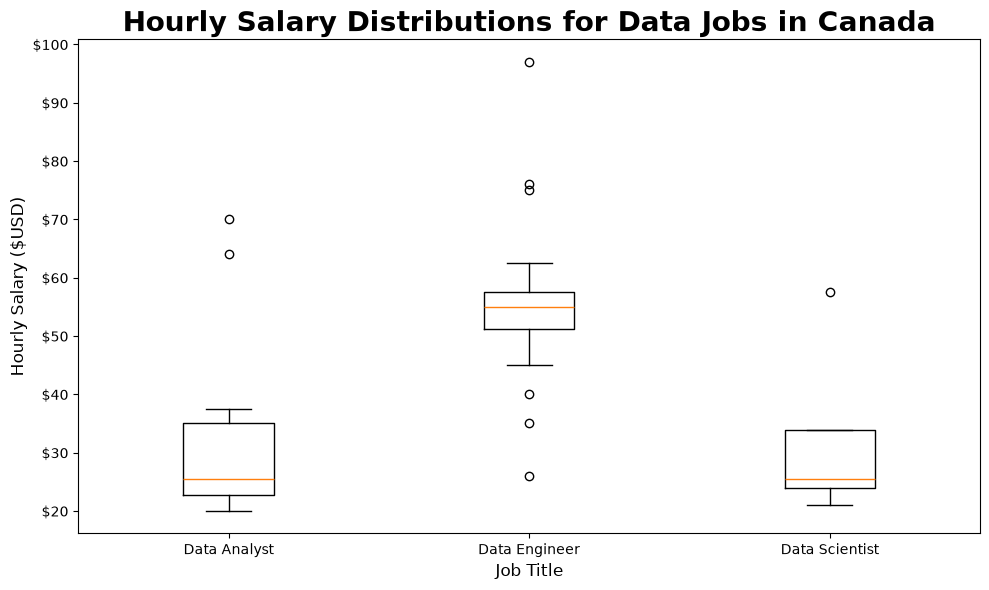

In [66]:
plt.figure(figsize=(10, 6))

plt.boxplot(job_list
            , vert = True)

plt.title(
        'Hourly Salary Distributions for Data Jobs in Canada'
        , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Job Title'
            , fontdict={'fontsize': 12})

plt.ylabel(
            'Hourly Salary ($USD)'
            , fontdict={'fontsize': 12})

ax = plt.gca()
ax.set_xticklabels(labels=job_titles)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y)}'))

plt.tight_layout(h_pad=1, w_pad = 1)
plt.show()
